<a href="https://colab.research.google.com/github/soseverse/Application-of-remote-sensing-and-deep-learning---Sand-mining-detection-at-Vietnam-Mekong-Delta/blob/colab-progress/sm_project_oversampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.0 MB/s eta 0:00:00


### imported libraries

In [ ]:
pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import os
import shutil
import yaml
import matplotlib.pyplot as plt
import random

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
from IPython.display import display

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### load dataset

In [ ]:
dataset_path = '/content/drive/MyDrive/sm_vmd_data'

def show_contents(path):
  for name in os.listdir(path):
    full_path = os.path.join(path, name)
    if os.path.isdir(full_path):
      print(f'{name}/ - {len(os.listdir(full_path))} files')

In [ ]:
show_contents(dataset_path)

train_labels/ - 3502 files
train_images/ - 3502 files


### dataset cleaning

In [ ]:
def remove_empty_labels(old_dir, new_dir):
  os.makedirs(new_dir, exist_ok = True)
  count = 0 # to count number of files with empty label
  for name in os.listdir(old_dir):
    full_path = os.path.join(old_dir, name)
    if os.path.isfile(full_path) and os.path.getsize(full_path) > 0:
      shutil.copy(full_path, new_dir)
    else:
      count = count + 1

  print(f'Total empty label files: {count}')

In [ ]:
label_dir = os.path.join(dataset_path, 'train_labels')
cleaned_data_dir = os.path.join(dataset_path, 'cleaned_dataset')

remove_empty_labels(label_dir, cleaned_data_dir)

Total empty label files: 326


### analysis of annotated objects

In [ ]:
# check data.yaml file
with open("/content/drive/MyDrive/sm_vmd_data/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)


In [ ]:
nc = data_yaml['nc']
names = data_yaml['names']


### Get class IDs

In [ ]:
all_class_counts = {}

for filename in os.listdir(cleaned_data_dir):
    if not filename.endswith(".txt"):
        continue

    with open(os.path.join(cleaned_data_dir, filename)) as file:
        for line in file:
            class_id = int(line.split()[0])

            if class_id not in all_class_counts:
                all_class_counts[class_id] = 1
            else:
               all_class_counts[class_id] += 1


In [ ]:
all_class_counts

{2: 16727, 1: 5996, 0: 2848, 3: 255}

### valid classes

In [ ]:
for class_id in range(nc):
    class_name = names[class_id]
    count = all_class_counts[class_id]
    print(f"Class {class_id} ({class_name}): {count}")

Class 0 (barge with crane): 2848
Class 1 (cluster of boats): 5996
Class 2 (sand transport boat): 16727


### Handling invalid class

In [ ]:
invalid_classes = []

for class_id, count in all_class_counts.items():
    if class_id >= nc:
        invalid_classes.append((class_id, count))

if len(invalid_classes) > 0:
    print("\nInvalid classes found:")
    for item in invalid_classes:
        cid = item[0]
        count = item[1]
        print(f"Class ID {cid}: {count} annotations")
else:
    print("\nNo invalid classes found.")



Invalid classes found:
Class ID 3: 255 annotations


### Dataset Visualisation

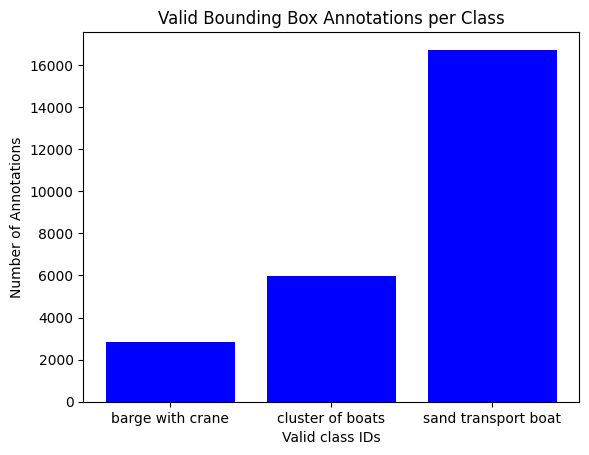

In [ ]:
class_ids = list(range(nc))
counts = [all_class_counts[class_id] for class_id in class_ids]
labels = [names[class_id] for class_id in class_ids]

plt.figure()
plt.bar(labels, counts, color = 'blue')
plt.xlabel("Valid class IDs")
plt.ylabel("Number of Annotations")
plt.title("Valid Bounding Box Annotations per Class")
plt.show()


### Dataset analysis wrt images

In [ ]:
class_images = {}

for filename in os.listdir(cleaned_data_dir):
    if not filename.endswith(".txt"):
        continue

    with open(os.path.join(cleaned_data_dir, filename)) as file:
        for line in file:
            class_id = int(line.split()[0])

            if class_id not in class_images:
                class_images[class_id] = []

            if filename not in class_images[class_id]:
                class_images[class_id].append(filename)


In [ ]:
print("Total images per valid class:")

for class_id in range(nc):
    class_name = names[class_id]
    image_count = len(class_images[class_id])
    print(f"Class {class_id} ({class_name}): {image_count} images")


Total images per valid class:
Class 0 (barge with crane): 1494 images
Class 1 (cluster of boats): 1878 images
Class 2 (sand transport boat): 2619 images


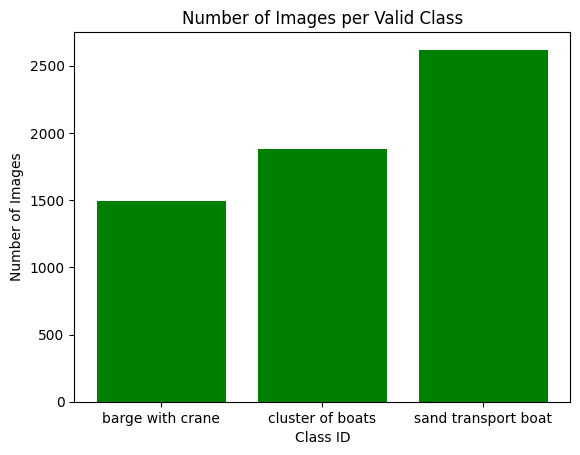

In [ ]:
valid_class_ids = []
image_counts = []

for class_id in range(nc):
    valid_class_ids.append(names[class_id])

    if class_id in class_images:
        image_counts.append(len(class_images[class_id]))
    else:
        image_counts.append(0)

plt.figure()
plt.bar(valid_class_ids, image_counts, color = 'green')
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Number of Images per Valid Class")
plt.show()


### Validation dataset

In [ ]:
image_classes = {}

for filename in os.listdir(cleaned_data_dir):
  if not filename.endswith('txt'):
    continue
  with open(os.path.join(cleaned_data_dir, filename)) as file:
    for line in file:
      class_id = int(line.split()[0])
      if filename not in image_classes:
        image_classes[filename] = []

      if class_id not in image_classes[filename]:
        image_classes[filename].append(class_id)

In [ ]:
class_image_counts = {}

for classes in image_classes.values():
  for class_id in classes:
    if class_id not in class_image_counts:
      class_image_counts[class_id] = 1
    else:
      class_image_counts[class_id] += 1

In [ ]:
val_size = 0.20
target_val_counts = {}
for class_id in range(nc):
  if class_id in class_image_counts:
    target_val_counts[class_id] = int(class_image_counts[class_id] * val_size)
  else:
    target_val_counts[class_id] = 0

In [ ]:
target_val_counts

{0: 298, 1: 375, 2: 523}

### Extract validation images from dataset

In [ ]:
val_counts = {}

for class_id in target_val_counts:
  val_counts[class_id] = target_val_counts[class_id]

# store validation images in new list
val_images = []
image_names = list(image_classes.keys())
random.shuffle(image_names)

for image_name in image_names:
  classes = image_classes[image_name]
  for class_id in classes:
    if class_id in val_counts:
      if val_counts[class_id] > 0:
        val_images.append(image_name)

        # receeding count of val_counts
        for class_ in classes:
          if class_ in val_counts:
            if val_counts[class_] > 0:
              val_counts[class_] -= 1
        break


In [ ]:
train_images = []

for image_name in image_classes:
  if image_name not in val_images:
    train_images.append(image_name)

print(f'Total validation images: ({len(val_images)})')
print(f'Total training images: ({len(train_images)})')

Total validation images: (636)
Total training images: (2540)


In [ ]:
new_dataset_path = 'vmd'

train_images_dir = os.path.join(new_dataset_path, 'images/train')
train_labels_dir = os.path.join(new_dataset_path, 'labels/train')

val_images_dir = os.path.join(new_dataset_path, 'images/val')
val_labels_dir = os.path.join(new_dataset_path, 'labels/val')

os.makedirs(train_images_dir, exist_ok = True)
os.makedirs(train_labels_dir, exist_ok = True)
os.makedirs(val_images_dir, exist_ok = True)
os.makedirs(val_labels_dir, exist_ok = True)



### for train images

In [ ]:
for label_name in train_images:

    image_name = label_name.replace(".txt", ".jpg")

    shutil.copy(
        os.path.join("/content/drive/MyDrive/sm_vmd_data/train_images", image_name),
        os.path.join(train_images_dir, image_name)
    )


    shutil.copy(
        os.path.join(cleaned_data_dir, label_name),
        os.path.join(train_labels_dir, label_name)
    )


### for validation images

In [ ]:
for label_name in val_images:

    image_name = label_name.replace(".txt", ".jpg")

    shutil.copy(
        os.path.join("/content/drive/MyDrive/sm_vmd_data/train_images", image_name),
        os.path.join(val_images_dir, image_name)
    )

    shutil.copy(
        os.path.join(cleaned_data_dir, label_name),
        os.path.join(val_labels_dir, label_name)
    )


In [ ]:
print("Train images:", len(os.listdir(train_images_dir)))
print("Train labels:", len(os.listdir(train_labels_dir)))
print("Val images:", len(os.listdir(val_images_dir)))
print("Val labels:", len(os.listdir(val_labels_dir)))


Train images: 2540
Train labels: 2540
Val images: 636
Val labels: 636


## VGG 16 - Baseline Model

### create VGG-16 dataset for classification

In [ ]:
images_dir = "/content/vmd/images/train"
labels_dir = "/content/vmd/labels/train"
vgg_16_path = "/content/vgg_16"

os.makedirs(vgg_16_path, exist_ok=True)

for label_file in os.listdir(labels_dir):

    if not label_file.endswith(".txt"):
        continue

    image_file = label_file.replace(".txt", ".jpg")

    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(labels_dir, label_file)

    if not os.path.exists(image_path):
        continue

    img = Image.open(image_path)
    w, h = img.size

    with open(label_path) as f:
        for i, line in enumerate(f):

            parts = line.split()
            class_id = int(parts[0])

            if class_id >= 3:
                continue
            # Yolo coordinates
            xc = float(parts[1])
            yc = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            # Bounding box axis boundary
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            # invalid crops
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img.crop((x1, y1, x2, y2))

            class_folder = os.path.join(vgg_16_path, str(class_id))
            os.makedirs(class_folder, exist_ok=True)

            save_name = f"{label_file[:-4]}_{i}.jpg"
            save_path = os.path.join(class_folder, save_name)

            crop.save(save_path)

print("VGG16 crops created successfully.")


VGG16 crops created successfully.


In [ ]:
print(os.listdir(vgg_16_path))

['0', '2', '1']


### Splitting crops into train and validation set

In [ ]:
source_dir = "/content/vgg_16"
base_dir = "/content/vgg16_data"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

random.seed(42)

for class_id in os.listdir(source_dir):

    class_source = os.path.join(source_dir, class_id)
    if not os.path.isdir(class_source):
        continue

    class_train = os.path.join(train_dir, class_id)
    class_val   = os.path.join(val_dir, class_id)

    os.makedirs(class_train, exist_ok=True)
    os.makedirs(class_val, exist_ok=True)

    images = os.listdir(class_source)
    random.shuffle(images)

    split_idx = int(len(images) * 0.8)

    train_imgs = images[:split_idx]
    val_imgs   = images[split_idx:]

    for img in train_imgs:
        shutil.copy(os.path.join(class_source, img),
                    os.path.join(class_train, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_source, img),
                    os.path.join(class_val, img))


### Data Preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)


In [ ]:
train_generator = train_datagen.flow_from_directory(
    "/content/vgg16_data/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "/content/vgg16_data/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)


Found 16564 images belonging to 3 classes.
Found 4142 images belonging to 3 classes.


### Building VGG-16 Model

In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
output = Dense(3, activation="softmax")(x)




In [ ]:
model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


518/518 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.7247 - loss: 0.9526 - val_accuracy: 0.7921 - val_loss: 0.5427
Epoch 2/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.7944 - loss: 0.5385 - val_accuracy: 0.7603 - val_loss: 0.6088
Epoch 3/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8152 - loss: 0.4884 - val_accuracy: 0.7774 - val_loss: 0.6016
Epoch 4/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8234 - loss: 0.4663 - val_accuracy: 0.8081 - val_loss: 0.5195
Epoch 5/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8297 - loss: 0.4488 - val_accuracy: 0.8274 - val_loss: 0.4821
Epoch 6/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8452 - loss: 0.4243 - val_accuracy: 0.8267 - val_loss: 0.4887
Epoch 7/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8453 - loss: 0.4089 - val_accuracy: 0.8184 - val_loss: 0.4913
Epoch 8/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8511 - loss: 0.3965 - val_accurac

### Check accuracy and loss for baseline model

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)


130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8178 - loss: 0.4786
Validation Loss: 0.4718072712421417
Validation Accuracy: 0.8285852074623108


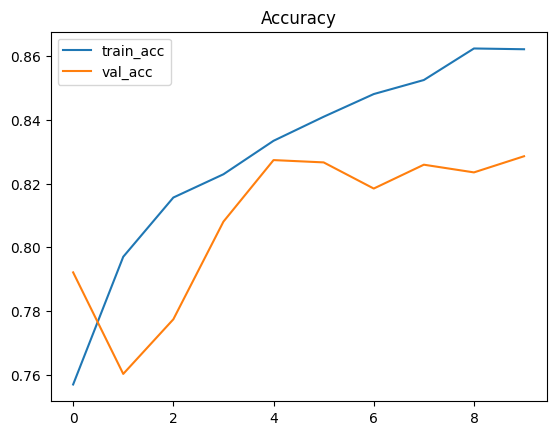

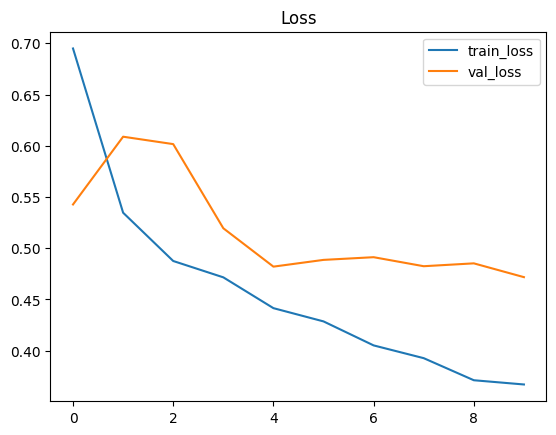

In [ ]:
# Accuracy plot
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


### VGG-16 Model tuning

In [ ]:
# Adding 4 more layers
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False


In [ ]:
model_ft1 = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_ft1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft1 = model_ft1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.8845 - loss: 0.3131 - val_accuracy: 0.8404 - val_loss: 0.4426
Epoch 2/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8988 - loss: 0.2741 - val_accuracy: 0.8457 - val_loss: 0.4374
Epoch 3/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9072 - loss: 0.2508 - val_accuracy: 0.8542 - val_loss: 0.4210
Epoch 4/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9200 - loss: 0.2211 - val_accuracy: 0.8597 - val_loss: 0.4289
Epoch 5/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9305 - loss: 0.1999 - val_accuracy: 0.8522 - val_loss: 0.4426


In [ ]:
val_loss, val_acc = model_ft1.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)


130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8460 - loss: 0.4561
Validation Loss: 0.4426366090774536
Validation Accuracy: 0.8522452712059021


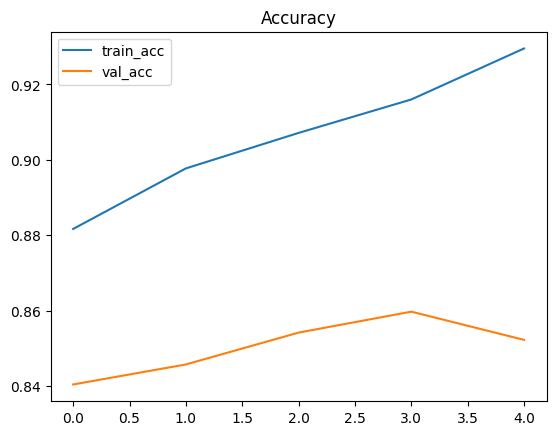

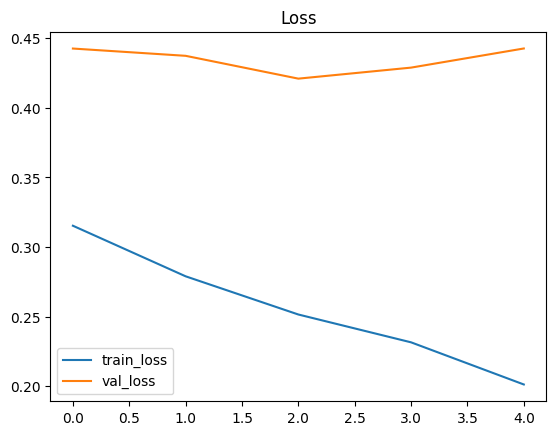

In [ ]:
# Accuracy plot
plt.plot(history_ft1.history["accuracy"], label="train_acc")
plt.plot(history_ft1.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_ft1.history["loss"], label="train_loss")
plt.plot(history_ft1.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


In [ ]:
# Adding another 8 layers
for layer in base_model.layers[:-8]:
    layer.trainable = False



In [ ]:
model_ft2 = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_ft2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft2 = model_ft2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9406 - loss: 0.1698 - val_accuracy: 0.8576 - val_loss: 0.4457
Epoch 2/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.9450 - loss: 0.1614 - val_accuracy: 0.8636 - val_loss: 0.4218
Epoch 3/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9527 - loss: 0.1454 - val_accuracy: 0.8634 - val_loss: 0.4287
Epoch 4/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9533 - loss: 0.1389 - val_accuracy: 0.8675 - val_loss: 0.4283
Epoch 5/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9613 - loss: 0.1253 - val_accuracy: 0.8667 - val_loss: 0.4405


In [ ]:
val_loss_vgg, val_acc_vgg = model_ft2.evaluate(val_generator)

print("Validation Loss:", val_loss_vgg)
print("Validation Accuracy:", val_acc_vgg)


130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8571 - loss: 0.4642
Validation Loss: 0.44045668840408325
Validation Accuracy: 0.8667310476303101


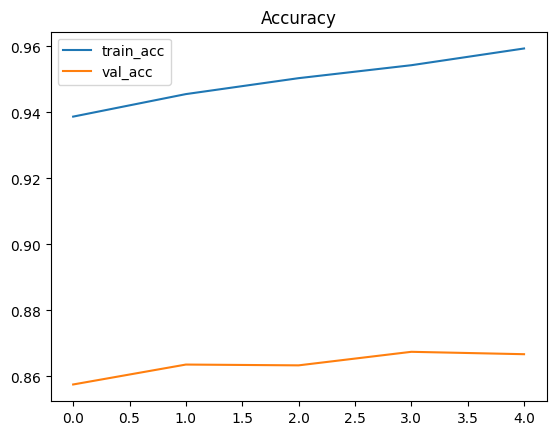

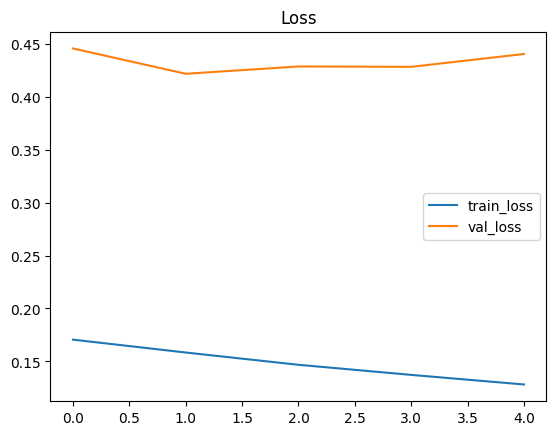

In [ ]:
# Accuracy plot
plt.plot(history_ft2.history["accuracy"], label="train_acc")
plt.plot(history_ft2.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_ft2.history["loss"], label="train_loss")
plt.plot(history_ft2.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


### Test Model

In [ ]:
true_labels = val_generator.classes
val_generator.reset()
predictions = model_ft1.predict(val_generator)
pred_labels = np.argmax(predictions, axis=1)

130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step


### Confusion Matrix

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)



Confusion Matrix:
[[  41  108  309]
 [  77  173  696]
 [ 247  586 1905]]


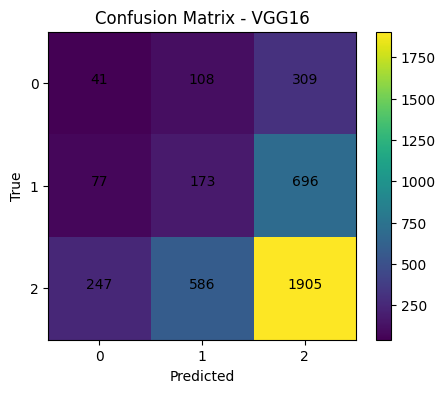

In [ ]:
# Visualise confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap='viridis')
plt.title("Confusion Matrix - VGG16")
plt.colorbar()

class_names = list(val_generator.class_indices.keys())
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# Add values to the plot
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 horizontalalignment="center")

plt.show()



### Classification Report

In [ ]:
print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

           0       0.11      0.09      0.10       458
           1       0.20      0.18      0.19       946
           2       0.65      0.70      0.67      2738

    accuracy                           0.51      4142
   macro avg       0.32      0.32      0.32      4142
weighted avg       0.49      0.51      0.50      4142



### Building the ResNet-50 Model

In [ ]:
# Let's work with a Pre-trained Imagenet model
resnet_base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
resnet_base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
x = resnet_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)

output = Dense(3, activation="softmax")(x)




In [ ]:
resnet_model = Model(inputs=resnet_base_model.input, outputs=output)

In [ ]:
resnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
    )

Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.6670 - loss: 0.8447 - val_accuracy: 0.6726 - val_loss: 0.8152
Epoch 2/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6850 - loss: 0.7958 - val_accuracy: 0.6750 - val_loss: 0.8059
Epoch 3/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6803 - loss: 0.8057 - val_accuracy: 0.6806 - val_loss: 0.8003
Epoch 4/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.6879 - loss: 0.7891 - val_accuracy: 0.6799 - val_loss: 0.7899
Epoch 5/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6920 - loss: 0.7761 - val_accuracy: 0.6837 - val_loss: 0.7841
Epoch 6/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.6947 - loss: 0.7722 - val_accuracy: 0.6840 - val_loss: 0.7816
Epoch 7/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.6928 - loss: 0.7699 - val_accuracy: 0.6803 - val_loss: 0.8322
Epoch 8/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6947 - loss: 0.7768 - 

In [ ]:
val_loss_resnet, val_acc_resnet = resnet_model.evaluate(val_generator)

print("ResNet50 Final Validation Accuracy:", val_acc_resnet)
print("ResNet50 Final Validation Loss:", val_loss_resnet)

130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7017 - loss: 0.7349
ResNet50 Final Validation Accuracy: 0.70014488697052
ResNet50 Final Validation Loss: 0.7423845529556274


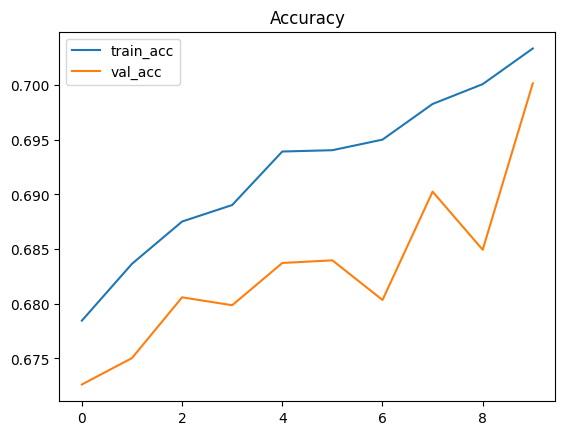

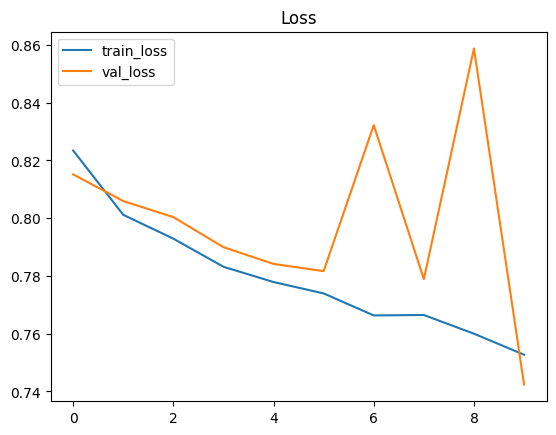

In [ ]:
# Accuracy plot
plt.plot(history_resnet.history["accuracy"], label="train_acc")
plt.plot(history_resnet.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_resnet.history["loss"], label="train_loss")
plt.plot(history_resnet.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


In [ ]:
# checking number of layers
len(resnet_base_model.layers)

175

### Finetuning ResNet50

In [ ]:
resnet_base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


In [ ]:
resnet_model_ft1 = Model(inputs=resnet_base_model.input, outputs=output)

In [ ]:
resnet_model_ft1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_resnet_ft1 = resnet_model_ft1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 114s 116ms/step - accuracy: 0.6527 - loss: 5.2937 - val_accuracy: 0.6610 - val_loss: 6.6065
Epoch 2/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.7719 - loss: 0.8357 - val_accuracy: 0.7211 - val_loss: 1.5098
Epoch 3/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.8258 - loss: 0.5126 - val_accuracy: 0.7962 - val_loss: 0.6921
Epoch 4/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.8563 - loss: 0.4021 - val_accuracy: 0.8081 - val_loss: 0.6225
Epoch 5/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.8866 - loss: 0.3150 - val_accuracy: 0.8426 - val_loss: 0.5515


In [ ]:
val_loss_resnet, val_acc_resnet = resnet_model_ft1.evaluate(val_generator)

print("ResNet50 Final Validation Accuracy:", val_acc_resnet)
print("ResNet50 Final Validation Loss:", val_loss_resnet)


130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8465 - loss: 0.5388
ResNet50 Final Validation Accuracy: 0.8425881266593933
ResNet50 Final Validation Loss: 0.5514513254165649


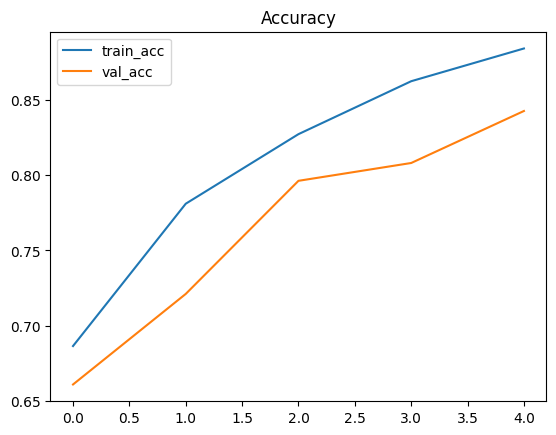

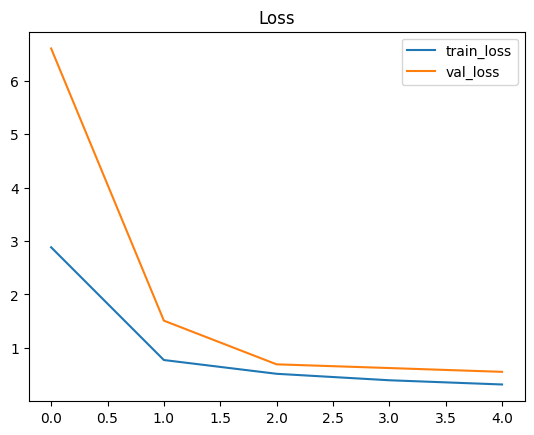

In [ ]:
# Accuracy plot
plt.plot(history_resnet_ft1.history["accuracy"], label="train_acc")
plt.plot(history_resnet_ft1.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_resnet_ft1.history["loss"], label="train_loss")
plt.plot(history_resnet_ft1.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


In [ ]:
resnet_base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False


In [ ]:
resnet_model_ft2 = Model(inputs=resnet_base_model.input, outputs=output)

In [ ]:
resnet_model_ft2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_resnet_ft2 = resnet_model_ft2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 106s 107ms/step - accuracy: 0.8389 - loss: 0.5132 - val_accuracy: 0.8274 - val_loss: 0.5130
Epoch 2/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.8962 - loss: 0.2805 - val_accuracy: 0.8279 - val_loss: 0.4992
Epoch 3/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.9201 - loss: 0.2248 - val_accuracy: 0.8585 - val_loss: 0.4681
Epoch 4/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.9502 - loss: 0.1438 - val_accuracy: 0.8725 - val_loss: 0.4322
Epoch 5/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.9611 - loss: 0.1144 - val_accuracy: 0.8831 - val_loss: 0.4617


In [ ]:
val_loss_resnet, val_acc_resnet = resnet_model_ft2.evaluate(val_generator)

print("ResNet50 Final Validation Accuracy:", val_acc_resnet)
print("ResNet50 Final Validation Loss:", val_loss_resnet)


130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8829 - loss: 0.4508
ResNet50 Final Validation Accuracy: 0.8831482529640198
ResNet50 Final Validation Loss: 0.461740642786026


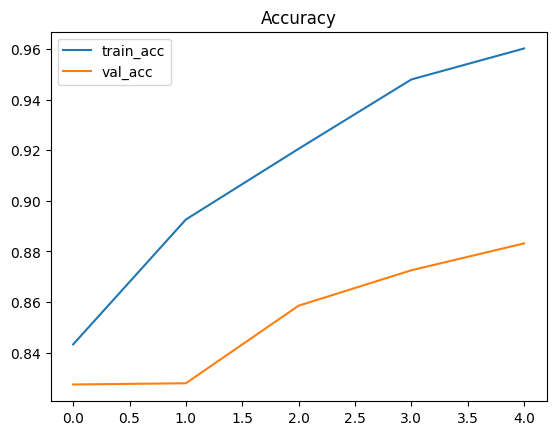

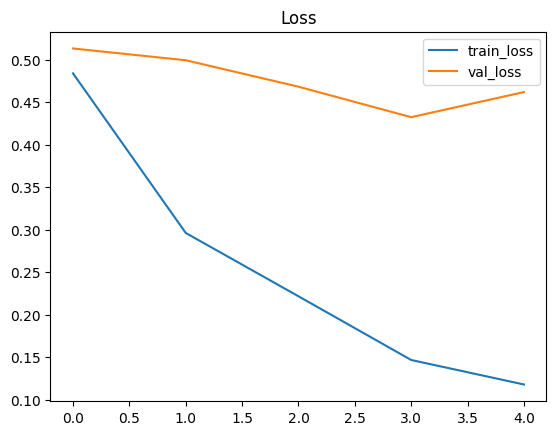

In [ ]:
# Accuracy plot
plt.plot(history_resnet_ft2.history["accuracy"], label="train_acc")
plt.plot(history_resnet_ft2.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_resnet_ft2.history["loss"], label="train_loss")
plt.plot(history_resnet_ft2.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()


### Confusion matrix for ResNet-50

In [ ]:
val_generator.reset()
resnet_predictions = resnet_model_ft2.predict(val_generator)
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)

130/130 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step


Confusion Matrix - ResNet50:
[[  45  108  305]
 [  95  194  657]
 [ 246  608 1884]]


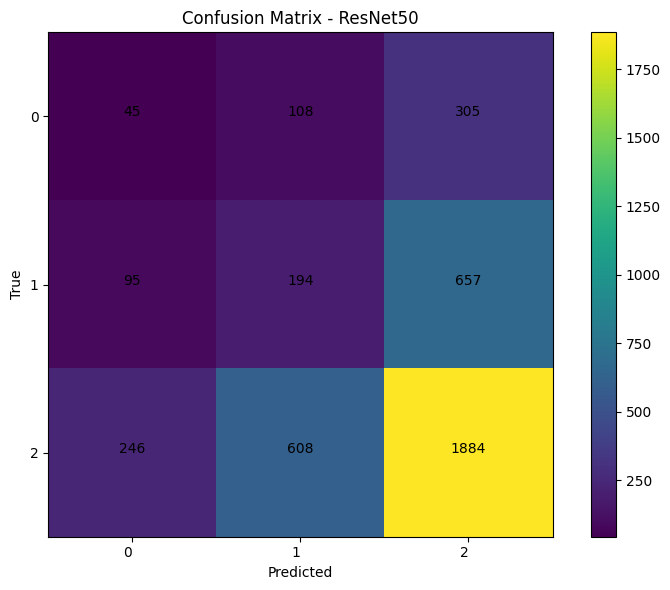

In [ ]:
cm_resnet = confusion_matrix(true_labels, resnet_pred_labels)
print("Confusion Matrix - ResNet50:")
print(cm_resnet)

plt.figure(figsize=(8, 6))
plt.imshow(cm_resnet, interpolation='nearest', cmap='viridis')
plt.title("Confusion Matrix - ResNet50")
plt.colorbar()

class_names = list(val_generator.class_indices.keys())
plt.xticks(range(len(class_names)), class_names, ha='right')
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# Add values to the plot
for i in range(cm_resnet.shape[0]):
    for j in range(cm_resnet.shape[1]):
        plt.text(j, i, str(cm_resnet[i, j]),
                 horizontalalignment="center")

plt.tight_layout()
plt.show()

In [ ]:
print("\nResNet50 Classification Report:")
print(classification_report(true_labels, resnet_pred_labels, target_names=class_names))


ResNet50 Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.10      0.11       458
           1       0.21      0.21      0.21       946
           2       0.66      0.69      0.67      2738

    accuracy                           0.51      4142
   macro avg       0.33      0.33      0.33      4142
weighted avg       0.50      0.51      0.51      4142



### Classification Model Comparison

In [ ]:
print(f"VGG16:  Acc: {val_acc_vgg:.4f}, Loss: {val_loss_vgg:.4f}")
print(f"ResNet50: Acc: {val_acc_resnet:.4f}, Loss: {val_loss_resnet:.4f}")

VGG16:  Acc: 0.8667, Loss: 0.4405
ResNet50: Acc: 0.8831, Loss: 0.4617


## Building Yolo-v8 Model

In [ ]:
model = YOLO("yolov8m.pt")

In [ ]:
print(os.listdir("/content/vmd/images/train")[:5])
print(os.listdir("/content/vmd/images/val")[:5])

['243-5-_png.rf.419df8429a2fffaada83bc58fd85e2ad.jpg', 'Screenshot-217-_png.rf.30ee94bf7b7a6564a1cf2b39c174fdaa.jpg', '190-5-_png.rf.3f3e721cf8b712f33bb0a28df00896fe.jpg', '212-2-_png.rf.34065a249a79352cab3b6fba4c23d10e.jpg', '025-6-_png.rf.0ccfa3a79b934115d46caa98f20501eb.jpg']
['0116_jpg.rf.20d49d090593319a57ef2c03e45d9861.jpg', '213-5-_png.rf.ce0a3e60c48db46175252051b75b4a30.jpg', 'Screenshot-178-_png.rf.cf6cbba7b8bee3f8e4dc87d94c062b6a.jpg', 'Screenshot-105-_png.rf.1841a57e45b412e50799cb3a860ce35b.jpg', '118-3-_png.rf.a762680b6680fe4c802bb96b343652ec.jpg']


### Sample images and bounding box annotation

In [ ]:
filtered_images = []

for image_name in all_train_images:
    label_name = image_name.replace('.jpg', '.txt')
    label_path = os.path.join(train_labels_dir, label_name)

    valid_object_count = 0

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) < 5:
                    continue

                class_id = int(parts[0])

                if class_id >= nc:
                    continue

                valid_object_count += 1

    # After processing all lines in the label file, check if valid_object_count is between 1 and 3
    if 1 <= valid_object_count <= 3:
        filtered_images.append(image_name)

print(f"Found {len(filtered_images)} images with 1 to 3 valid objects.")

Found 1005 images with 1 to 3 valid objects.


In [ ]:
sample_curated_images = random.sample(filtered_images, min(5, len(filtered_images)))
print(f"Selected {len(sample_curated_images)} random curated images for visualization: {sample_curated_images}")

Selected 5 random curated images for visualization: ['Screenshot-268-_png.rf.c30837100789dd5175bfc3f683174ed0.jpg', '019-2-_png.rf.6729411970e1f87f57499a2169712a89.jpg', '072-2-_png.rf.6732b43c0722984a87f856d84250589d.jpg', '126_png.rf.2b550d7d2dcbfc37564afe67a6882b87.jpg', '040-3-_png.rf.5b66d0795c8a9c2b0e6d11382e8a4663.jpg']


Displaying annotations for curated image: Screenshot-268-_png.rf.c30837100789dd5175bfc3f683174ed0.jpg


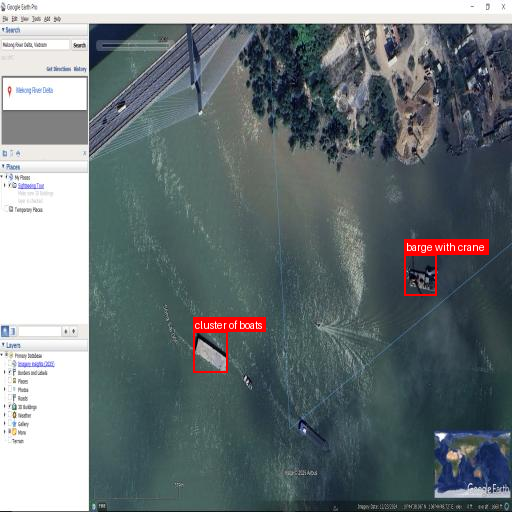

Displaying annotations for curated image: 019-2-_png.rf.6729411970e1f87f57499a2169712a89.jpg


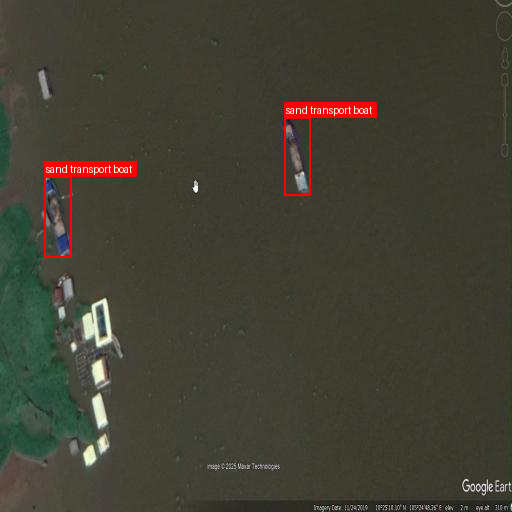

Displaying annotations for curated image: 072-2-_png.rf.6732b43c0722984a87f856d84250589d.jpg


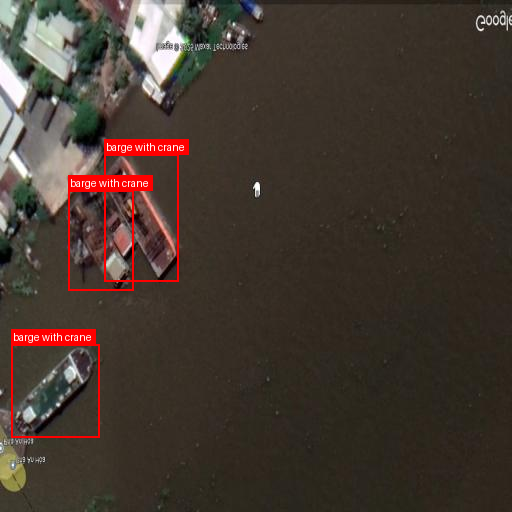

Displaying annotations for curated image: 126_png.rf.2b550d7d2dcbfc37564afe67a6882b87.jpg


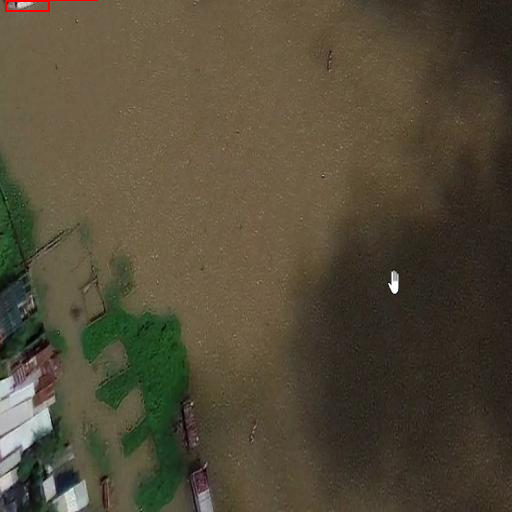

Displaying annotations for curated image: 040-3-_png.rf.5b66d0795c8a9c2b0e6d11382e8a4663.jpg


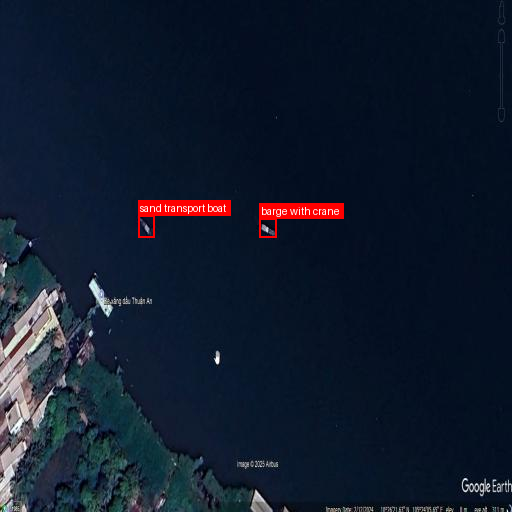

In [ ]:
for img_name in sample_curated_images:
    print(f"Displaying annotations for curated image: {img_name}")
    visualize_annotations(img_name, train_images_dir, train_labels_dir, names)

### First Yolo training

In [ ]:
results = model.train(
    data="/content/drive/MyDrive/sm_vmd_data/data.yaml",
    epochs=100,
    imgsz=768,
    batch=32,
    patience = 20,
    device = 0
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sm_vmd_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")

In [ ]:
metrics = model.val()
metrics

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1103.3±425.5 MB/s, size: 27.0 KB)
val: Scanning /content/vmd/labels/val.cache... 636 images, 0 backgrounds, 10 corrupt: 100% ━━━━━━━━━━━━ 636/636 205.2Mit/s 0.0s
val: /content/vmd/images/val/0026_jpg.rf.37dd6ab0757add74e13c0ee7b93652e3.jpg: 1 duplicate labels removed
val: /content/vmd/images/val/Screenshot-263-_png.rf.1c0d17daf24931581d3dc2a991e5306c.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/vmd/images/val/Screenshot-265-_png.rf.96471af7489b85aa452e3bd186bc193d.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/vmd/images/val/Screenshot-269-_png.rf.7d1bdb78cf49b1c77ea860eff80ba4f8.jpg: ignoring corrupt image/l

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d7534e03b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

### Second Yolo training

In [ ]:
model = YOLO("yolov8l.pt")

results = model.train(
    data="/content/drive/MyDrive/sm_vmd_data/data.yaml",
    epochs=200,
    imgsz=1024,
    batch=32,
    patience=50,
    device=0
)


Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sm_vmd_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru